In [1]:
from datasets import load_dataset as hf_load

# Download CPPE-5 from HuggingFace (train + test splits)
cppe5 = hf_load("rishitdagli/cppe-5")
print(f"Splits: {list(cppe5.keys())}")
for name, ds in cppe5.items():
    print(f"  {name}: {len(ds)} images")

/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating train split:  30%|███       | 300/1000 [00:00<00:00, 1608.24 examples/s]

Generating train split:  60%|██████    | 600/1000 [00:00<00:00, 2083.70 examples/s]

Generating train split: 100%|██████████| 1000/1000 [00:00<00:00, 2399.91 examples/s]

Generating train split: 100%|██████████| 1000/1000 [00:00<00:00, 2226.52 examples/s]

Generating test split:   0%|          | 0/29 [00:00<?, ? examples/s]

Generating test split: 100%|██████████| 29/29 [00:00<00:00, 2560.14 examples/s]

Splits: ['train', 'test']
  train: 1000 images
  test: 29 images


In [2]:
import json
from pathlib import Path

from datasets import Dataset

data_path = Path("./data/cppe5")


def write_imagefolder(hf_dataset: Dataset, root: Path) -> None:
    """Write a HuggingFace object-detection split in the ImageFolder convention."""
    root.mkdir(parents=True, exist_ok=True)

    with (root / "metadata.jsonl").open("w", encoding="utf-8") as fh:
        for seq, example in enumerate(hf_dataset):
            file_name = f"{seq:05d}.jpg"
            example["image"].convert("RGB").save(root / file_name, quality=95)

            objects = example["objects"]
            row = {
                "file_name": file_name,
                "objects": {
                    "bbox": [[float(v) for v in box] for box in objects["bbox"]],  # absolute-pixel xywh
                    "categories": [int(category) for category in objects["category"]],
                },
            }
            fh.write(json.dumps(row) + "\n")


for split_name, split in cppe5.items():
    write_imagefolder(split, data_path / split_name)
print(f"Saved to {data_path}")

Saved to data/cppe5


In [3]:
from dataeval.config import set_max_processes

from dataeval_flow.config import (
    DataAnalysisTaskConfig,
    DataAnalysisWorkflowConfig,
    HuggingFaceDatasetConfig,
    PipelineConfig,
    SourceConfig,
    ViewConfig,
    ViewOperation,
)
from dataeval_flow.workflow import run_task
from dataeval_flow.workflows.analysis.params import DataAnalysisHealthThresholds

set_max_processes(8)

analysis_workflow = DataAnalysisWorkflowConfig(
    name="cppe5_analysis",
    outlier_method="adaptive",
    outlier_flags=["dimension", "pixel", "visual"],
    outlier_threshold=4.0,
    balance=True,
    diversity_method="simpson",
    include_image_stats=True,
    health_thresholds=DataAnalysisHealthThresholds(
        image_outliers=5.0,  # Relaxed from 3% — CPPE-5 has diverse images
        exact_duplicates=0.0,  # No exact duplicates allowed (default)
        near_duplicates=5.0,  # Up to 5% near duplicates before warning (default)
        class_label_imbalance=5.0,  # CPPE-5 has moderate imbalance (default)
        distribution_shift=0.5,  # Default
    ),
)

task = DataAnalysisTaskConfig(
    name="cppe5-quality-check",
    workflow="cppe5_analysis",
    sources=["cppe5_trn_src", "cppe5_val_src", "cppe5_tst_src"],
)

config = PipelineConfig(
    datasets=[
        HuggingFaceDatasetConfig(name="cppe5_train", path=str(data_path), split="train", task="object_detection"),
        HuggingFaceDatasetConfig(name="cppe5_test", path=str(data_path), split="test", task="object_detection"),
    ],
    views=[
        ViewConfig(name="trn-500", operations=[ViewOperation(type="Limit", params={"size": 500})]),
        ViewConfig(
            name="val-50", operations=[ViewOperation(type="Indices", params={"indices": {"start": 500, "stop": 550}})]
        ),
    ],
    sources=[
        SourceConfig(name="cppe5_trn_src", dataset="cppe5_train", view="trn-500"),
        SourceConfig(name="cppe5_val_src", dataset="cppe5_train", view="val-50"),
        SourceConfig(name="cppe5_tst_src", dataset="cppe5_test"),
    ],
    workflows=[analysis_workflow],
    tasks=[task],
)

print("Configuration ready:")
print(f"  Workflow:   {analysis_workflow.name} (type={analysis_workflow.type})")
print(f"  Task:       {task.name} -> {task.workflow}")
print(f"  Sources:    {task.sources}")

Configuration ready:
  Workflow:   cppe5_analysis (type=data-analysis)
  Task:       cppe5-quality-check -> cppe5_analysis
  Sources:    ['cppe5_trn_src', 'cppe5_val_src', 'cppe5_tst_src']


In [4]:
result = run_task(task, config, cache_dir=Path("./cache"))

In [5]:
if not result.success:
    print(f"Workflow failed: {result.errors}")
assert result.success

In [6]:
print(result.report())


  DATASET ANALYSIS COMPLETE. 3 SPLIT(S), 579 TOTAL ITEMS.
  Timestamp:    2026-07-28T15:11:11.855958+00:00
  Duration:     31.50s
  Source:       cppe5_trn_src (cppe5_train[trn-500])
                cppe5_val_src (cppe5_train[val-50])
                cppe5_tst_src (cppe5_test)
--------------------------------------------------------------------------------

  SUMMARY
  -------
  Image Quality ....................... 51 outliers (41/500, 4/50, 6/29)  [!!]
  Redundancy ............................... 2 exact, 35 near duplicates  [!!]
  Label Balance ..................... 5 classes, imbalance 3.4/3.2/3.6:1  [..]
  Bias ................................ 49 factors checked, issues found  [!!]
  Label Overlap ..................... All 5 classes shared across splits  [ok]
  Label Parity ..................... 1/3 pair(s) significantly different  [!!]
  Leakage ..................... 2 exact + 16 near cross-split duplicates  [!!]

  Health: 5 warning(s) [!!] — review flagged findings

  IMAGE QU

In [7]:
import polars as pl

raw = result.data.raw

for pair_name, comparison in raw.cross_split.items():
    overlap = comparison.label_health.label_overlap

    # Check for split-exclusive classes
    split_only = {k: v for k, v in overlap.items() if k.endswith("_only") and v}
    if split_only:
        print(f"--- {pair_name}: MISSING CLASSES ---")
        for key, val in split_only.items():
            print(f"  {key}: {val}")
    else:
        shared = overlap.get("shared_classes", [])
        print(f"--- {pair_name}: all {len(shared)} classes present in both splits ---")

    # Proportion comparison table
    prop = overlap.get("proportion_comparison", {})
    if prop:
        prop_rows = []
        first = next(iter(prop.values()))
        pair_splits = [k for k in first if k != "difference"]
        for cls_name, vals in prop.items():
            row = {"Class": cls_name}
            for s in pair_splits:
                row[f"{s} (%)"] = round(vals[s] * 100, 1)
            row["Diff (pp)"] = round(vals["difference"] * 100, 1)
            prop_rows.append(row)
        df = pl.DataFrame(prop_rows).sort("Diff (pp)", descending=True)
        large_diffs = [c for c, v in prop.items() if abs(v["difference"]) > 0.05]
        if large_diffs:
            print(f"  {len(large_diffs)} class(es) differ by >5 percentage points between splits")
        print(df)
    print()

--- cppe5_trn_src_vs_cppe5_val_src: all 5 classes present in both splits ---
shape: (5, 4)
┌───────┬───────────────────┬───────────────────┬───────────┐
│ Class ┆ cppe5_trn_src (%) ┆ cppe5_val_src (%) ┆ Diff (pp) │
│ ---   ┆ ---               ┆ ---               ┆ ---       │
│ str   ┆ f64               ┆ f64               ┆ f64       │
╞═══════╪═══════════════════╪═══════════════════╪═══════════╡
│ 3     ┆ 8.4               ┆ 12.1              ┆ 3.7       │
│ 2     ┆ 28.8              ┆ 26.2              ┆ 2.6       │
│ 4     ┆ 28.5              ┆ 27.0              ┆ 1.5       │
│ 0     ┆ 25.4              ┆ 26.2              ┆ 0.8       │
│ 1     ┆ 8.9               ┆ 8.5               ┆ 0.5       │
└───────┴───────────────────┴───────────────────┴───────────┘

--- cppe5_trn_src_vs_cppe5_tst_src: all 5 classes present in both splits ---
  1 class(es) differ by >5 percentage points between splits
shape: (5, 4)
┌───────┬───────────────────┬───────────────────┬───────────┐
│ Class ┆ cpp

In [8]:
for pair_name, comparison in raw.cross_split.items():
    lp = comparison.label_health.label_parity
    if lp:
        if lp["significant"]:
            print(
                f"{pair_name}: SIGNIFICANT difference (chi2={lp['chi_squared']:.2f}, "
                f"p={lp['p_value']:.4g}) -- splits may not share the same label distribution"
            )
        else:
            print(f"{pair_name}: no significant difference (chi2={lp['chi_squared']:.2f}, p={lp['p_value']:.4g})")
    else:
        print(f"{pair_name}: label parity not computed")

cppe5_trn_src_vs_cppe5_val_src: no significant difference (chi2=4.95, p=0.2924)
cppe5_trn_src_vs_cppe5_tst_src: SIGNIFICANT difference (chi2=14.36, p=0.006233) -- splits may not share the same label distribution
cppe5_val_src_vs_cppe5_tst_src: no significant difference (chi2=4.64, p=0.326)



cppe5_trn_src: 1 exact duplicate group(s)

cppe5_trn_src: 13 near duplicate group(s)
  Group 1: ['cppe5_trn_src[59]', 'cppe5_trn_src[81]', 'cppe5_trn_src[176]']
  Group 2: ['cppe5_trn_src[72]', 'cppe5_trn_src[101]']
  Group 3: ['cppe5_trn_src[95]', 'cppe5_trn_src[110]', 'cppe5_trn_src[398]']
  Group 4: ['cppe5_trn_src[129]', 'cppe5_trn_src[340]', 'cppe5_trn_src[418]']
  Group 5: ['cppe5_trn_src[138]', 'cppe5_trn_src[167]']
  Group 6: ['cppe5_trn_src[143]', 'cppe5_trn_src[355]', 'cppe5_trn_src[357]']
  Group 7: ['cppe5_trn_src[153]', 'cppe5_trn_src[325]', 'cppe5_trn_src[442]']
  Group 8: ['cppe5_trn_src[165]', 'cppe5_trn_src[194]', 'cppe5_trn_src[257]', 'cppe5_trn_src[280]']
  Group 9: ['cppe5_trn_src[299]', 'cppe5_trn_src[417]']
  Group 10: ['cppe5_trn_src[300]', 'cppe5_trn_src[318]']
  Group 11: ['cppe5_trn_src[321]', 'cppe5_trn_src[412]']
  Group 12: ['cppe5_trn_src[331]', 'cppe5_trn_src[361]']
  Group 13: ['cppe5_trn_src[404]', 'cppe5_trn_src[413]']

cppe5_tst_src: 1 near duplicate

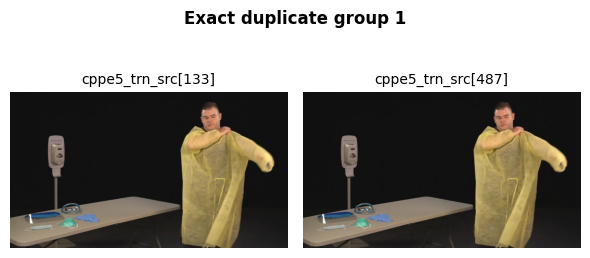

In [9]:
import matplotlib.pyplot as plt
import numpy as np

assert result.sources is not None


def plot_duplicate_group(dataset: object, indices: list[int], source_name: str, group_label: str) -> plt.Figure:
    """Plot a single duplicate group with source[idx] labels."""
    n = len(indices)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    if n == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices, strict=True):
        img = np.array(dataset[idx][0])  # type: ignore[index]
        if img.ndim == 3 and img.shape[0] in (1, 3, 4):
            img = img.transpose(1, 2, 0)
        ax.imshow(img)
        ax.set_title(f"{source_name}[{idx}]", fontsize=10)
        ax.axis("off")
    fig.suptitle(group_label, fontsize=12, fontweight="bold")
    fig.tight_layout()
    return fig


for split_name, split_data in raw.splits.items():
    rd = split_data.redundancy
    if rd.exact_groups:
        print(f"\n{split_name}: {len(rd.exact_groups)} exact duplicate group(s)")
        for i, group in enumerate(rd.exact_groups):
            plot_duplicate_group(result.sources[split_name], group, split_name, f"Exact duplicate group {i + 1}")
    if rd.near_groups:
        print(f"\n{split_name}: {len(rd.near_groups)} near duplicate group(s)")
        for i, group in enumerate(rd.near_groups):
            print(f"  Group {i + 1}: {[f'{split_name}[{idx}]' for idx in group]}")

cppe5_trn_src_vs_cppe5_val_src: DATA LEAKAGE DETECTED -- 0 exact, 8 near duplicates
  Near duplicate group 1: ['cppe5_trn_src[59]', 'cppe5_trn_src[81]', 'cppe5_trn_src[176]', 'cppe5_val_src[14]']
  Near duplicate group 2: ['cppe5_trn_src[153]', 'cppe5_trn_src[325]', 'cppe5_trn_src[442]', 'cppe5_val_src[3]']
cppe5_trn_src_vs_cppe5_tst_src: DATA LEAKAGE DETECTED -- 0 exact, 8 near duplicates
  Near duplicate group 1: ['cppe5_trn_src[72]', 'cppe5_trn_src[101]', 'cppe5_tst_src[27]']
  Near duplicate group 2: ['cppe5_trn_src[143]', 'cppe5_trn_src[355]', 'cppe5_trn_src[357]', 'cppe5_tst_src[18]', 'cppe5_tst_src[20]']
cppe5_val_src_vs_cppe5_tst_src: DATA LEAKAGE DETECTED -- 2 exact, 0 near duplicates


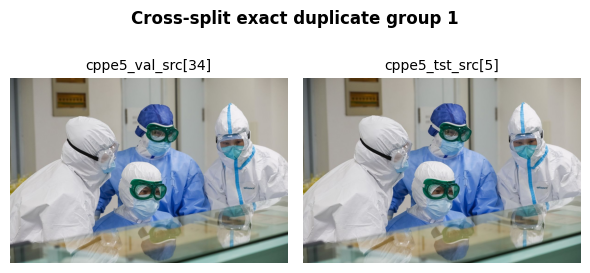

In [10]:
for pair_name, comparison in raw.cross_split.items():
    leakage = comparison.redundancy.duplicate_leakage
    exact_count = leakage.get("exact_count", 0)
    near_count = leakage.get("near_count", 0)
    if exact_count == 0 and near_count == 0:
        print(f"{pair_name}: No cross-split duplicates -- train/test integrity preserved")
        continue

    print(f"{pair_name}: DATA LEAKAGE DETECTED -- {exact_count} exact, {near_count} near duplicates")

    # Render exact duplicate groups — images from both splits side by side
    for i, group in enumerate(leakage.get("exact_groups", [])):
        all_images = []
        all_labels = []
        for split_name, indices in group.items():
            for idx in indices:
                img = np.array(result.sources[split_name][idx][0])
                if img.ndim == 3 and img.shape[0] in (1, 3, 4):
                    img = img.transpose(1, 2, 0)
                all_images.append(img)
                all_labels.append(f"{split_name}[{idx}]")
        if all_images:
            n = len(all_images)
            fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
            if n == 1:
                axes = [axes]
            for ax, img, label in zip(axes, all_images, all_labels, strict=True):
                ax.imshow(img)
                ax.set_title(label, fontsize=10)
                ax.axis("off")
            fig.suptitle(f"Cross-split exact duplicate group {i + 1}", fontsize=12, fontweight="bold")
            fig.tight_layout()

    # Print near duplicate leakage groups (skip rendering)
    for i, group in enumerate(leakage.get("near_groups", [])):
        labels = []
        for split_name, indices in group.items():
            labels.extend(f"{split_name}[{idx}]" for idx in indices)
        if labels:
            print(f"  Near duplicate group {i + 1}: {labels}")

In [11]:
json_str = result.export(fmt="json")
print(f"JSON output: {len(json_str)} characters")
print(json_str[:500] + "\n...")

JSON output: 1781187 characters
{
  "metadata": {
    "version": "1.0",
    "timestamp": "2026-07-28T15:11:11.855958Z",
    "dataset_id": "cppe5_train,cppe5_train,cppe5_test",
    "label_source": "huggingface",
    "model_id": null,
    "preprocessor_id": null,
    "selection_id": "trn-500,val-50",
    "source_descriptions": [
      "cppe5_trn_src (cppe5_train[trn-500])",
      "cppe5_val_src (cppe5_train[val-50])",
      "cppe5_tst_src (cppe5_test)"
    ],
    "resolved_config": {
      "sources": [
        {
          "name"
...
